In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd

In [3]:
df=pd.read_csv('day9_data.csv')

In [6]:
df.head()

,Gene_01,Gene_02,Gene_03,Gene_04,Gene_05,Gene_06,Gene_07,Gene_08,Gene_09,Gene_10,Target
0,0.49,-0.13,1.52,0.76,-0.46,-0.23,2.11,-1.02,0.33,0.85,153.42
1,-1.23,0.55,-0.88,1.12,0.05,0.77,-1.55,0.21,1.10,-0.66,-102.15
2,0.11,1.20,2.05,-0.33,1.44,-0.99,0.55,0.88,-0.22,0.14,124.60
3,-0.77,-1.40,-1.11,0.25,-0.88,1.33,-0.45,-0.75,0.66,1.20,-75.33
4,1.55,0.12,0.45,-1.20,0.67,-0.50,1.88,1.40,-1.05,-0.30,131.22


In [13]:
x=df.drop(columns='Target')

In [14]:
y=df.Target

In [16]:
x.head()

,Gene_01,Gene_02,Gene_03,Gene_04,Gene_05,Gene_06,Gene_07,Gene_08,Gene_09,Gene_10
0,0.49,-0.13,1.52,0.76,-0.46,-0.23,2.11,-1.02,0.33,0.85
1,-1.23,0.55,-0.88,1.12,0.05,0.77,-1.55,0.21,1.10,-0.66
2,0.11,1.20,2.05,-0.33,1.44,-0.99,0.55,0.88,-0.22,0.14
3,-0.77,-1.40,-1.11,0.25,-0.88,1.33,-0.45,-0.75,0.66,1.20
4,1.55,0.12,0.45,-1.20,0.67,-0.50,1.88,1.40,-1.05,-0.30


In [17]:
y.head()

0    153.42
1   -102.15
2    124.60
3    -75.33
4    131.22
Name: Target, dtype: float64

In [21]:
from sklearn.linear_model import LinearRegression as LR, Ridge, Lasso

In [19]:
ols=LR()

In [20]:
ols.fit(x,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[ 6.25,-2.67,45.8 ,...,10.4 ,-0.68,-4.58]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](10,)","['Gene_01','Gene_02','Gene_03',...,'Gene_08','Gene_09','Gene_10']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.649
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,10


In [22]:
ridge=Ridge(alpha=15)

In [23]:
ridge.fit(x,y)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",15
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' t

In [24]:
lasso=Lasso(alpha=15)

In [28]:
lasso.fit(x,y)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",15
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


In [29]:
print(f'OLS Co-efficients:\n {ols.coef_}')
print(f'Ridge Co-efficients:\n {ridge.coef_}')
print(f'Lasso Co-efficients:\n {lasso.coef_}')

OLS Co-efficients:
 [ 6.25203733 -2.66735273 45.79794318  2.87373573 -2.13729281  1.46651282
 42.03190339 10.4016276  -0.68138936 -4.58126038]
Ridge Co-efficients:
 [  7.12730303  -3.38879397  26.83631672  -5.60025046   4.11993041
  -9.42399596  27.18750286  -1.1702335  -13.65449101  -0.66860103]
Lasso Co-efficients:
 [ 0.         -0.         33.31154051 -0.          0.         -0.
 46.44262776  0.         -0.         -0.        ]


In [31]:
import numpy as np
import matplotlib.pyplot as plt


--- Generating The Lasso Coefficient Path Graph ---
Calculating how weights react as the Alpha penalty increases...


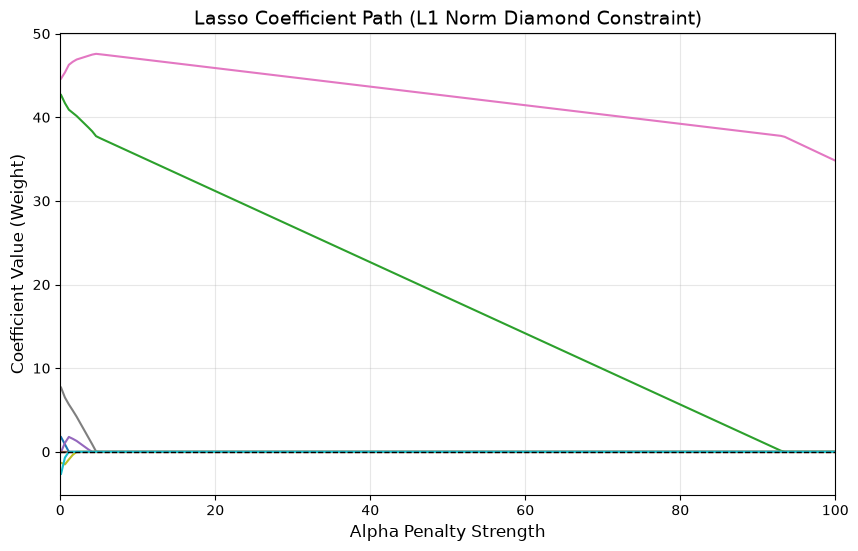

In [34]:
print("\n--- Generating The Lasso Coefficient Path Graph ---")
print("Calculating how weights react as the Alpha penalty increases...")

alphas = np.linspace(0.1, 100, 200)
lasso_coefs = []

for a in alphas:
    temp_lasso = Lasso(alpha=a)
    temp_lasso.fit(x, y)
    lasso_coefs.append(temp_lasso.coef_)

lasso_coefs = np.array(lasso_coefs)

plt.figure(figsize=(10, 6))
for i in range(10):
    plt.plot(alphas, lasso_coefs[:, i], label=f'Feature {i}')

plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title("Lasso Coefficient Path (L1 Norm Diamond Constraint)", fontsize=14)
plt.xlabel("Alpha Penalty Strength", fontsize=12)
plt.ylabel("Coefficient Value (Weight)", fontsize=12)
plt.xlim(0, 100)
plt.grid(True, alpha=0.3)
